In [2]:
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 117.3 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
from roboflow import Roboflow
from IPython.display import Image, display
from google.colab import files

import os, glob, yaml
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Libraries imported successfully.


In [4]:
from roboflow import Roboflow
rf = Roboflow(api_key="vvnltDQnN21B7ClLPQN4")
project = rf.workspace("maheshchhetri").project("weapon-detection-e6otc")
version = project.version(3)
dataset = version.download("yolov11")

print("Dataset downloaded at:", dataset.location)

print("Dataset downloaded successfully.")
print("Dataset location:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to weapon-detection-3 in yolov11:: 100%|██████████| 3738/3738 [00:00<00:00, 7879.28it/s]

Dataset downloaded at: /content/weapon-detection-3
Dataset downloaded successfully.
Dataset location: /content/weapon-detection-3


In [5]:
dataset_path = dataset.location
data_yaml_path = os.path.join(dataset_path, "data.yaml")

print("Dataset path:", dataset_path)
print("data.yaml exists:", os.path.exists(data_yaml_path))

print("\nDataset folder content:")
for item in os.listdir(dataset_path):
    print("-", item)


Dataset path: /content/weapon-detection-3
data.yaml exists: True

Dataset folder content:
- train
- valid
- data.yaml
- README.roboflow.txt
- README.dataset.txt
- test


In [6]:
with open(data_yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

print(data_yaml)

class_names = data_yaml.get("names", [])
print("\nClasses:", class_names)
print("Number of classes:", len(class_names))

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 4, 'names': ['Handgun', 'Knife', 'Rifle', 'Sword'], 'roboflow': {'workspace': 'maheshchhetri', 'project': 'weapon-detection-e6otc', 'version': 3, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/maheshchhetri/weapon-detection-e6otc/dataset/3'}}

Classes: ['Handgun', 'Knife', 'Rifle', 'Sword']
Number of classes: 4


In [7]:

def count_images(folder):
    exts = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]
    return sum(len(glob.glob(os.path.join(folder, ext))) for ext in exts)

train_img_dir = os.path.join(dataset_path, "train", "images")
valid_img_dir = os.path.join(dataset_path, "valid", "images")
test_img_dir = os.path.join(dataset_path, "test", "images")

counts = {
    "Train Images": count_images(train_img_dir),
    "Validation Images": count_images(valid_img_dir),
    "Test Images": count_images(test_img_dir)
}

pd.DataFrame([counts])

,Train Images,Validation Images,Test Images
0,1356,232,275


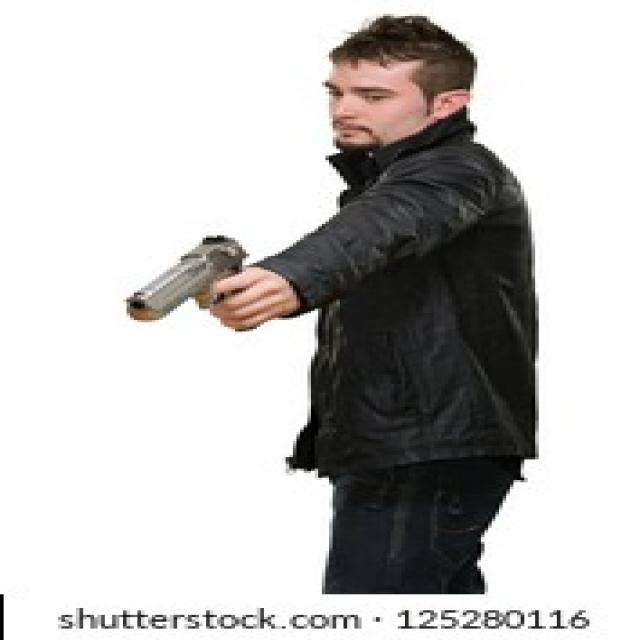

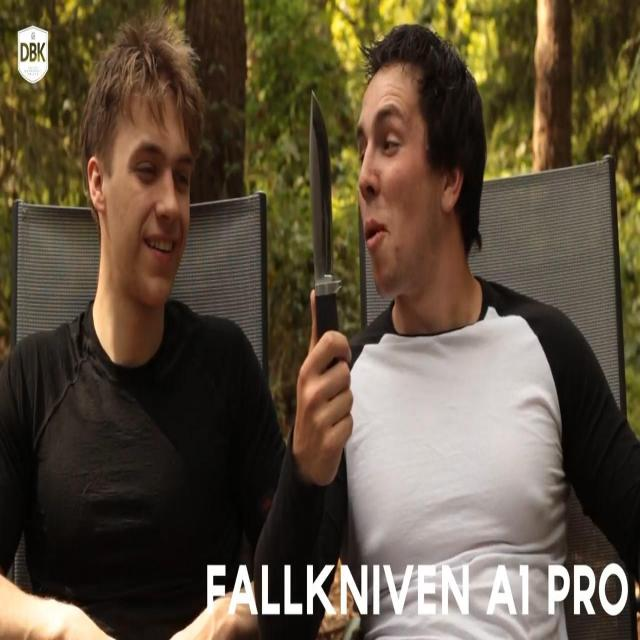

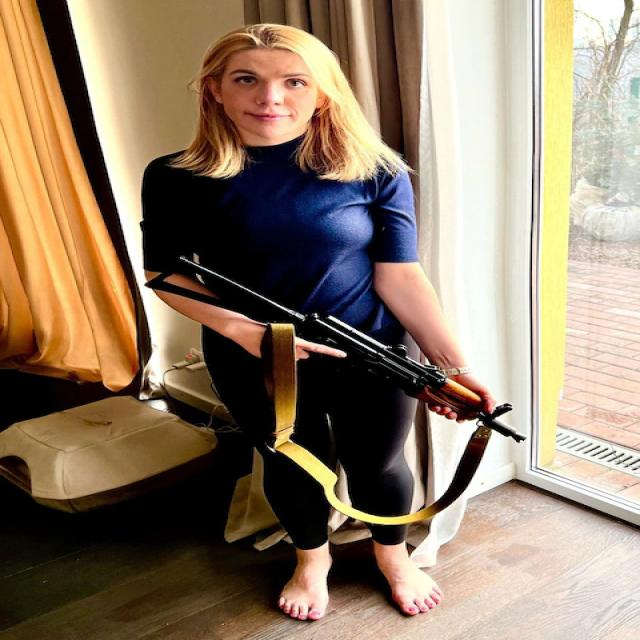

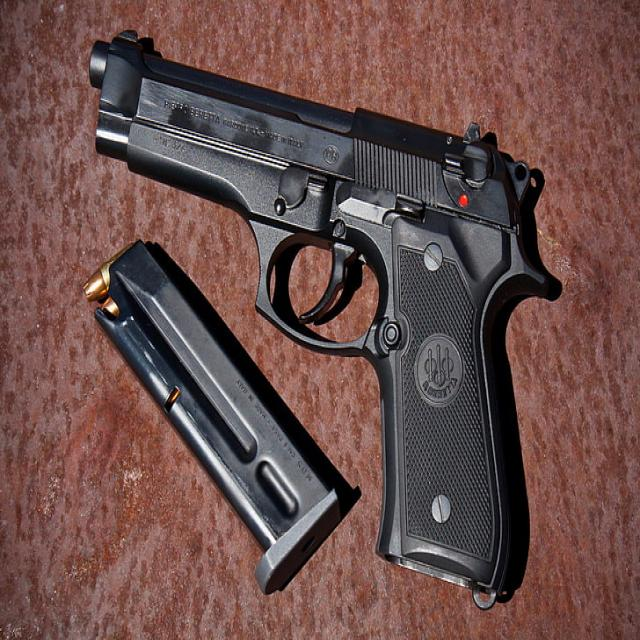

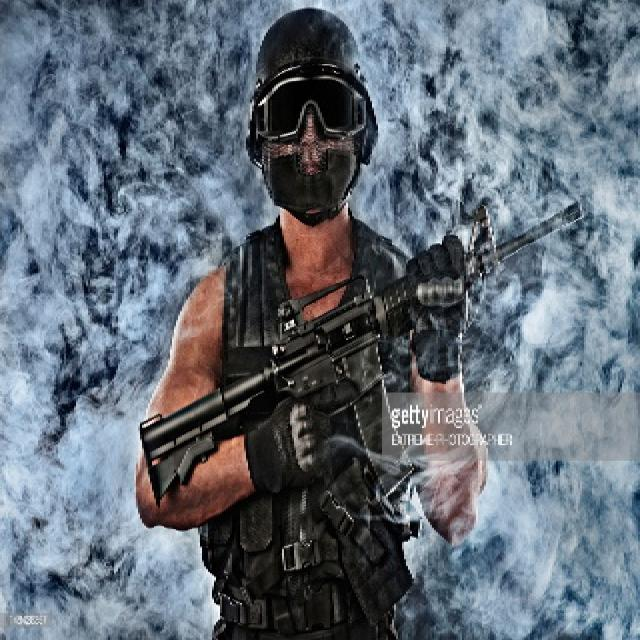

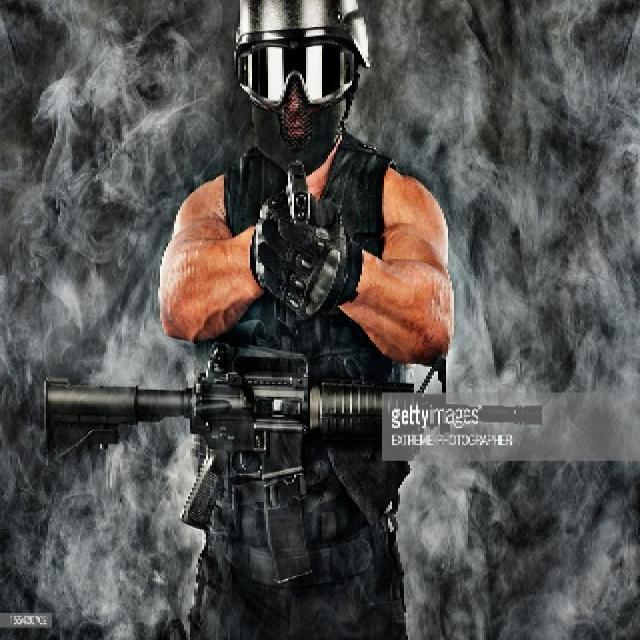

In [8]:
sample_images = glob.glob(os.path.join(train_img_dir, "*"))[:6]

for img in sample_images:
    display(Image(filename=img, width=400))


In [9]:
model = YOLO("yolov8n.pt")
print("YOLOv8 nano model loaded successfully.")

YOLOv8 nano model loaded successfully.


In [10]:
results = model.train(
    data=data_yaml_path,
    epochs=2,
    imgsz=640,
    batch=8,
    name="weapon_detection_yolov8_roboflow"
)


Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/weapon-detection-3/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=weapon_detection_yolov8_roboflow, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma


 results.png


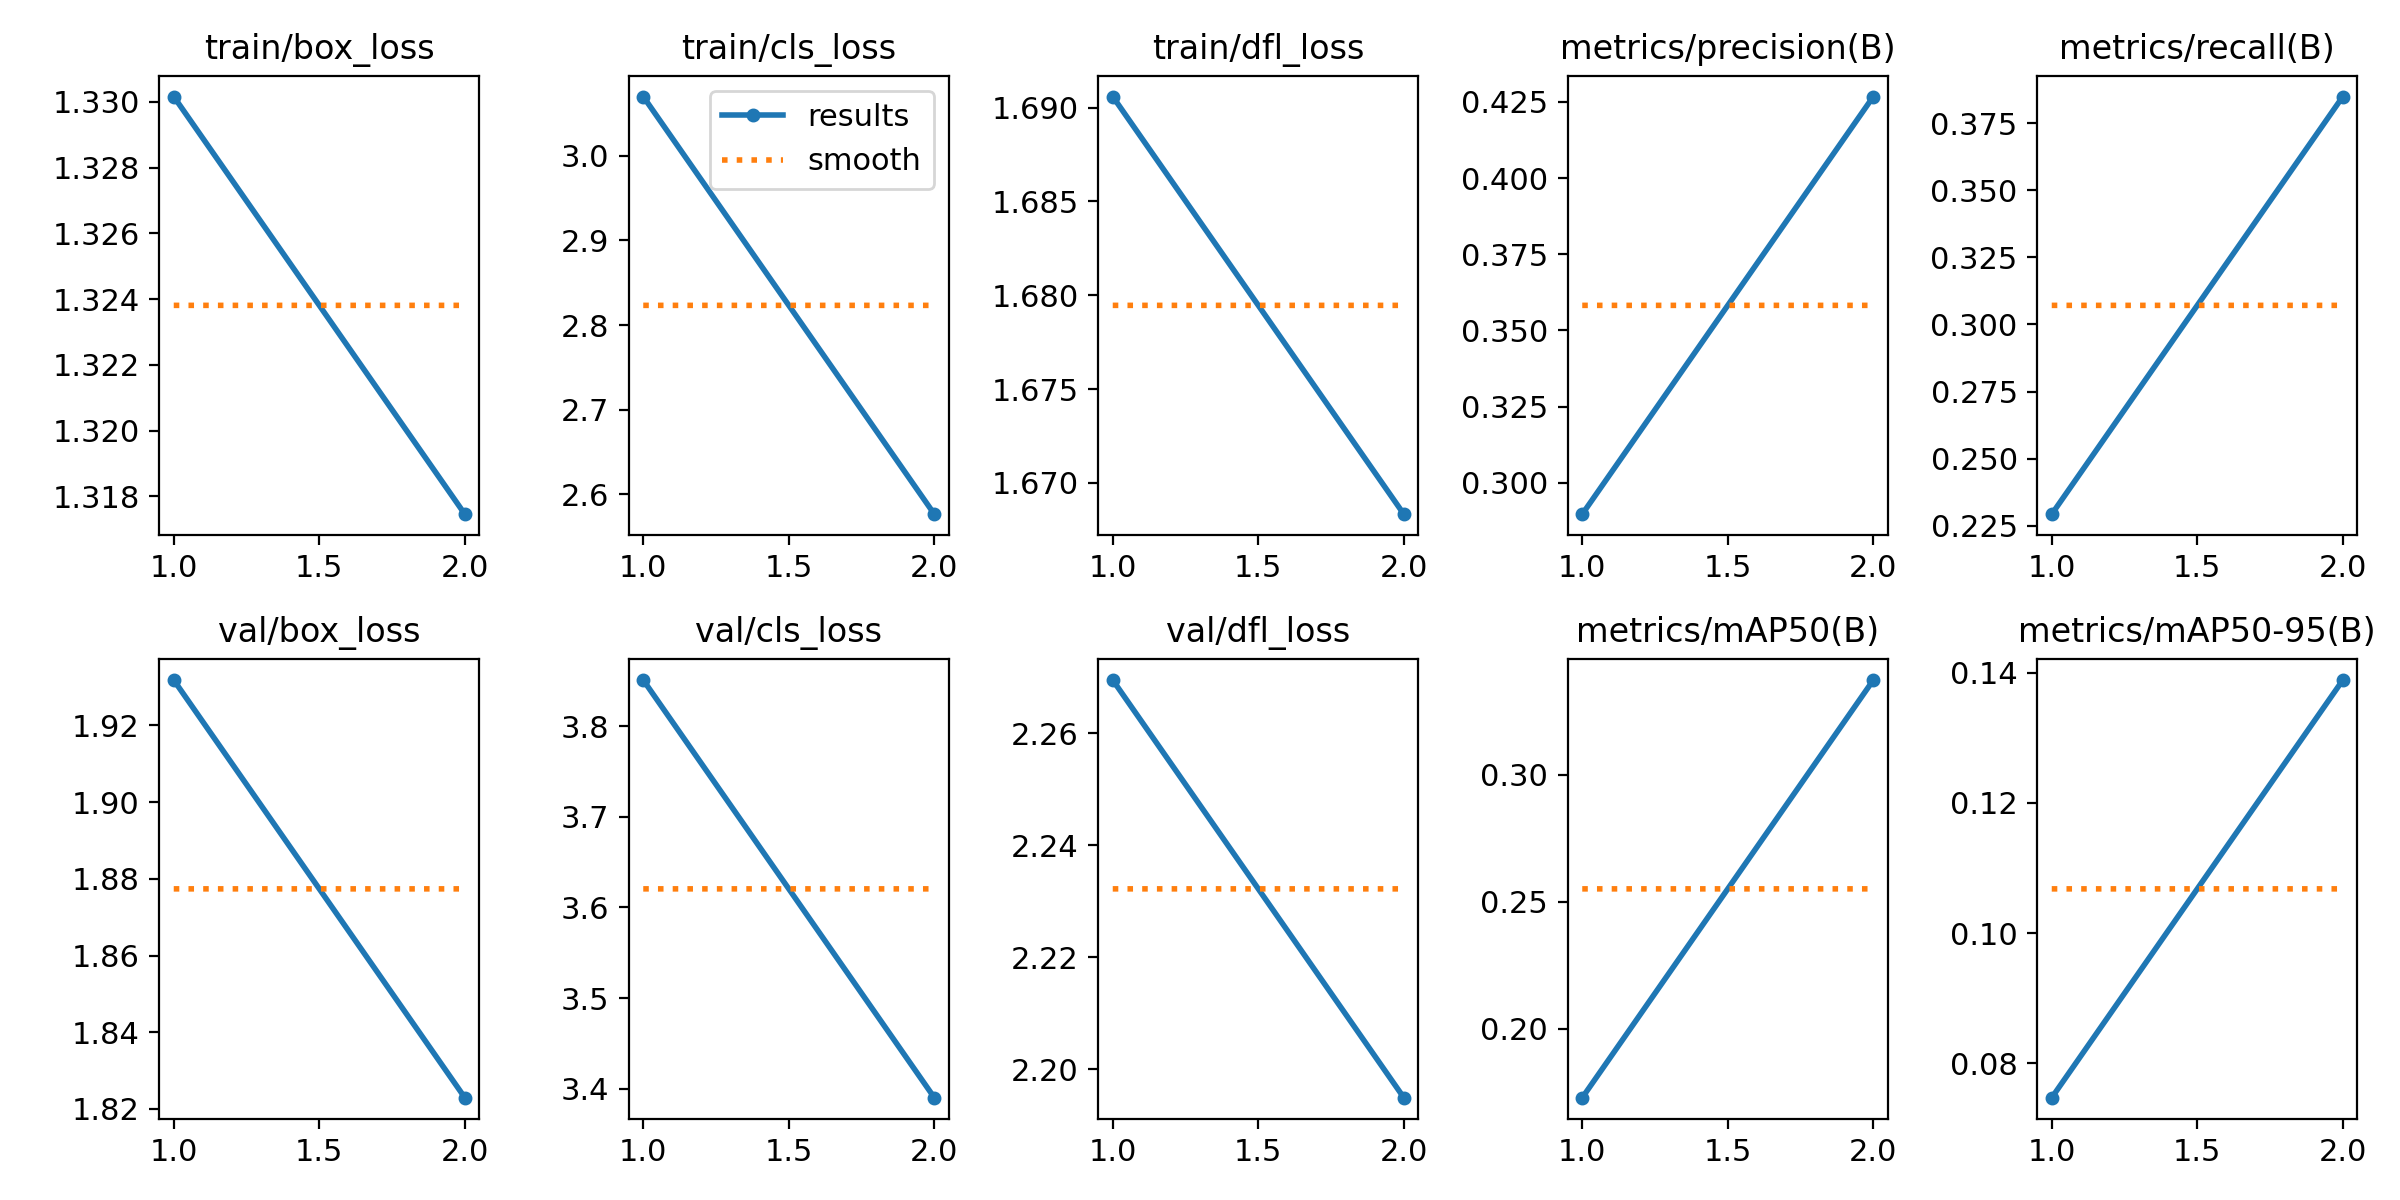


 confusion_matrix.png


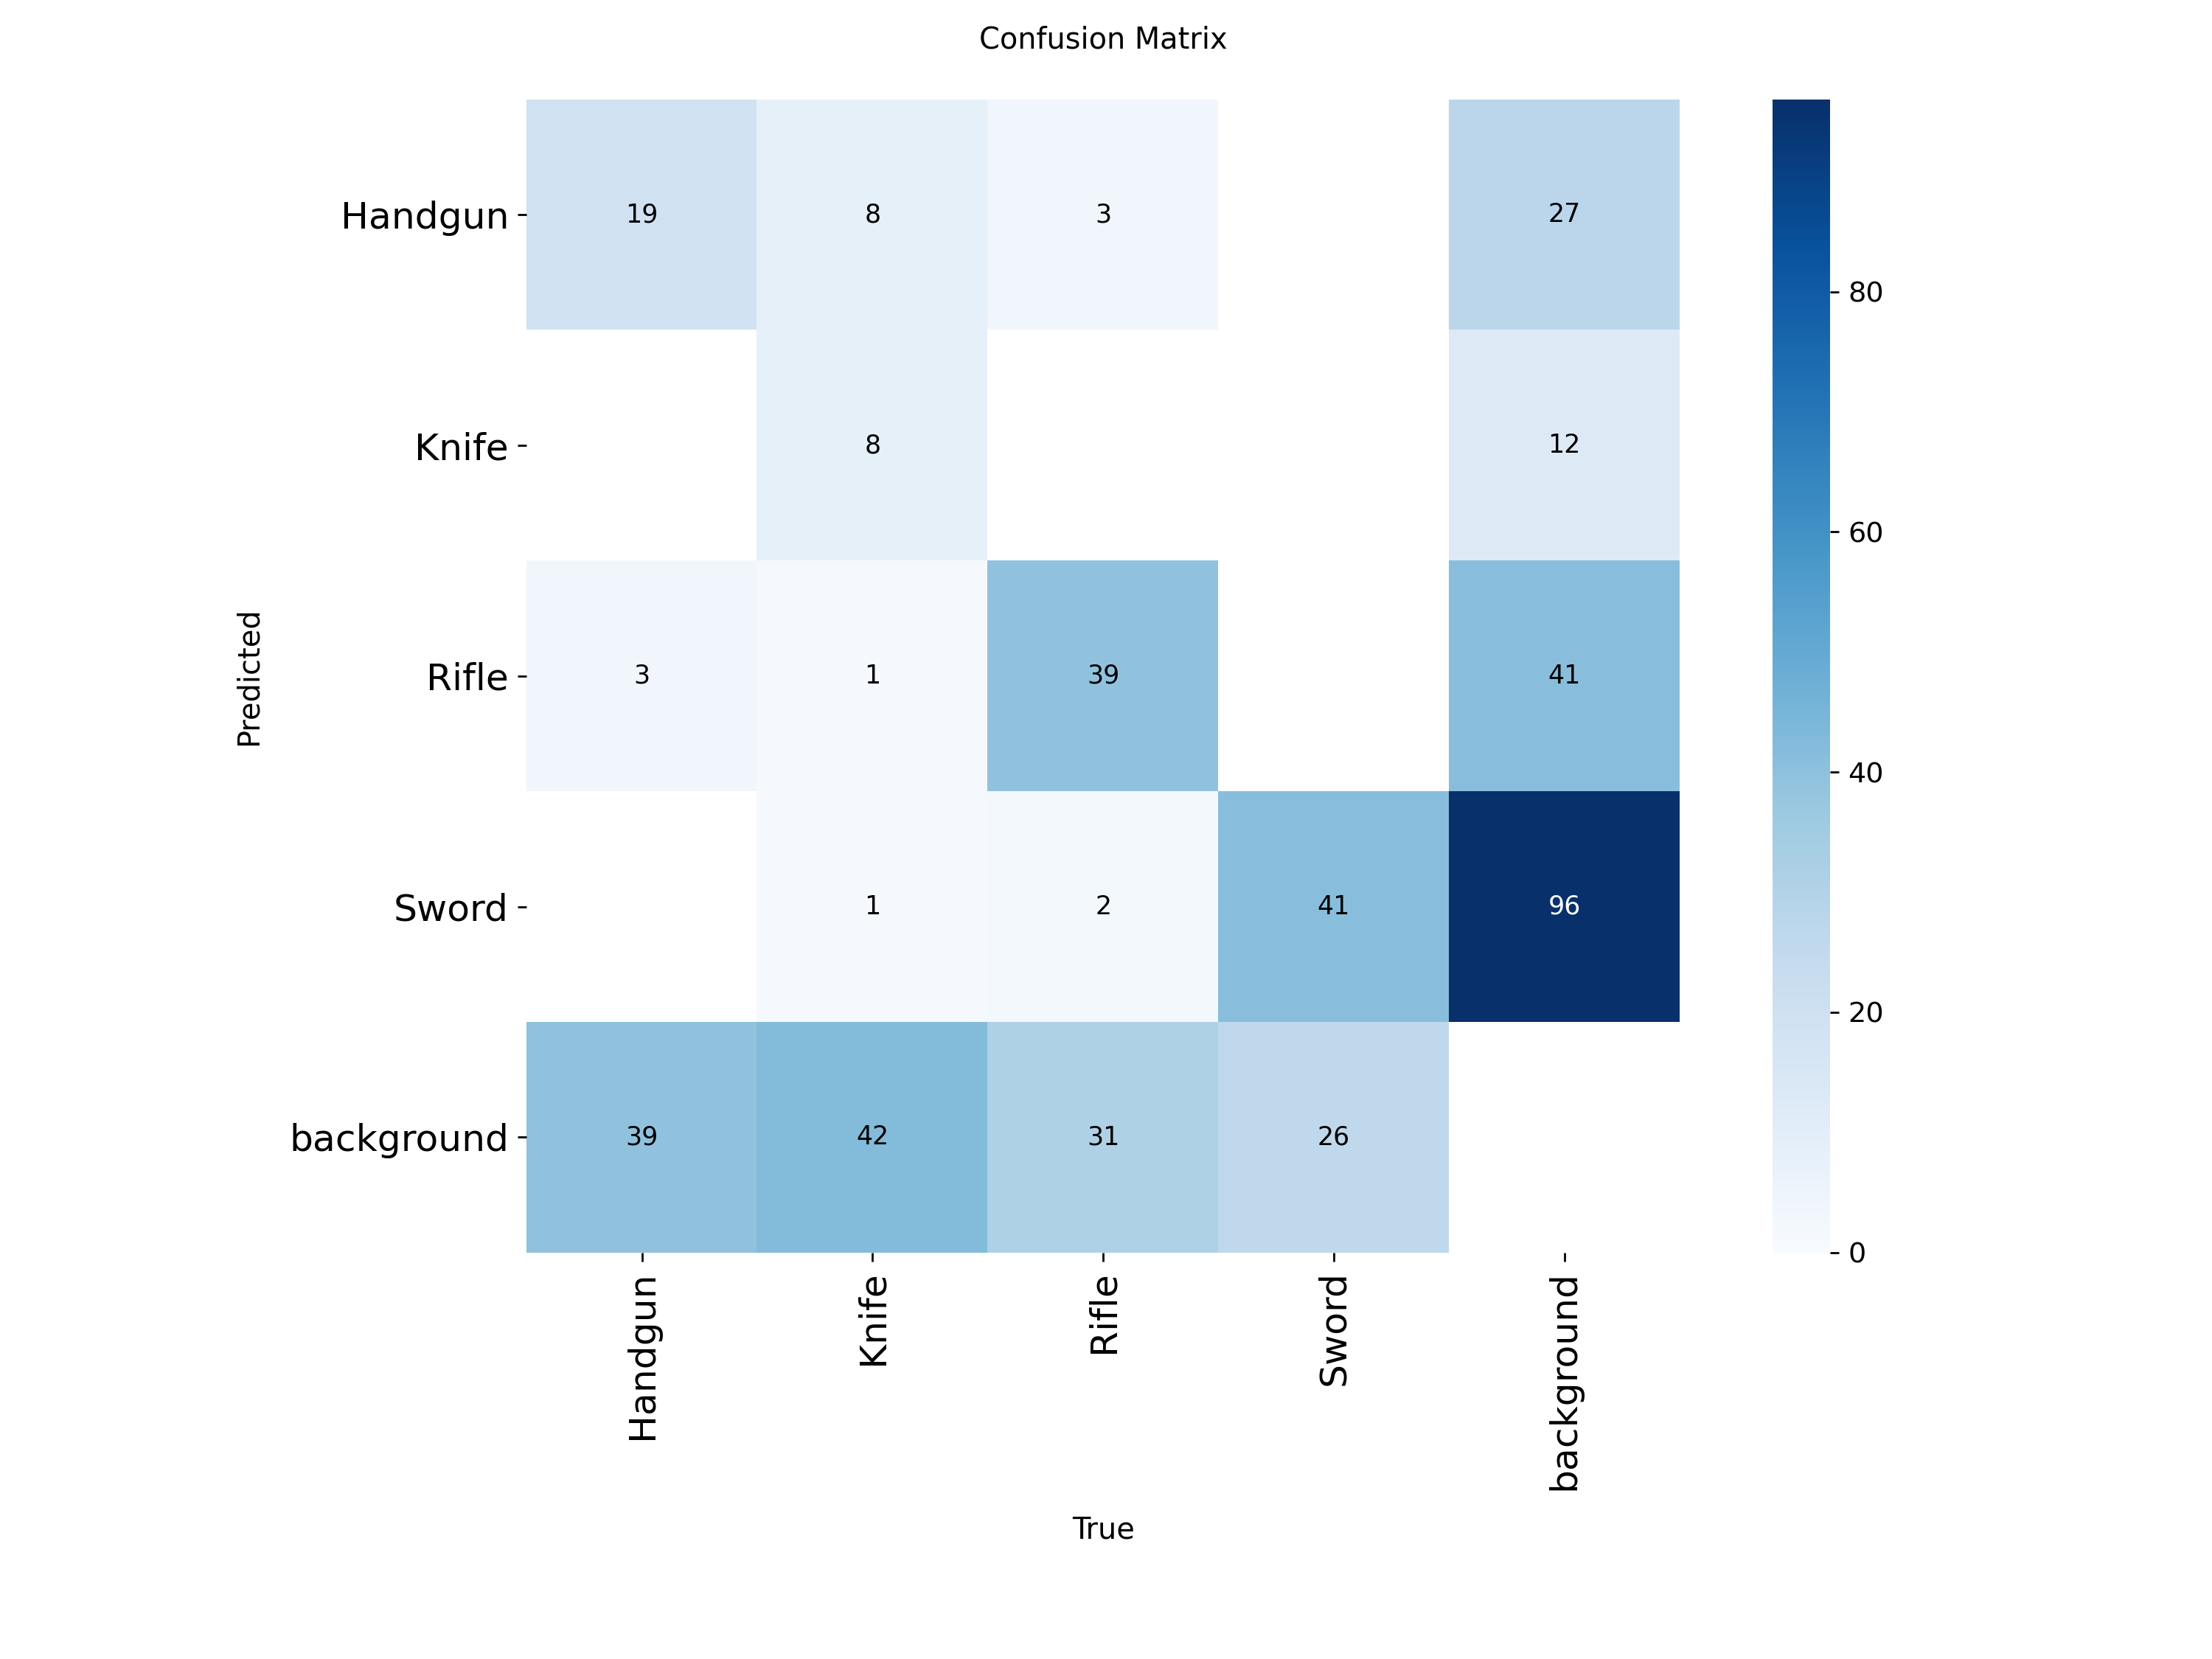

Not found: PR_curve.png
Not found: F1_curve.png
Not found: P_curve.png
Not found: R_curve.png


In [11]:
train_run_dir = "runs/detect/weapon_detection_yolov8_roboflow"

result_files = [
    "results.png",
    "confusion_matrix.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png"
]

for file in result_files:
    path = os.path.join(train_run_dir, file)
    if os.path.exists(path):
        print("\n", file)
        display(Image(filename=path, width=800))
    else:
        print("Not found:", file)



In [13]:
best_model_path = os.path.join(train_run_dir, "weights", "best.pt")
best_model = YOLO(best_model_path)

metrics = best_model.val(data=data_yaml_path)

print("Validation completed.")

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2013.3±804.8 MB/s, size: 41.8 KB)
val: Scanning /content/weapon-detection-3/valid/labels.cache... 232 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 232/232 97.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 3.0s/it 44.7s
                   all        232        263      0.426      0.383      0.336      0.139
               Handgun         59         61      0.408      0.311      0.285      0.119
                 Knife         56         60      0.434      0.133       0.16     0.0551
                 Rifle         66         75      0.555      0.533      0.511        0.2
                 Sword         53         67      0.307      0.552      0.388       0.18
Speed: 2.0ms preprocess, 180.3ms inference, 0.0

In [14]:
test_results = best_model.predict(
    source=test_img_dir,
    conf=0.4,
    save=True,
    name="weapon_detection_test_predictions"
)

print("Prediction completed on test images.")



image 1/275 /content/weapon-detection-3/test/images/073354cba4d11b34_jpg.rf.0eb5f21faa5914c97eab04a07c126380.jpg: 640x640 (no detections), 444.1ms
image 2/275 /content/weapon-detection-3/test/images/0b34b3483cc47a82_jpg.rf.a7ab004bee9f1ba7b1c0df5c1933a7af.jpg: 640x640 1 Sword, 245.0ms
image 3/275 /content/weapon-detection-3/test/images/145df260d0fdf32f_jpg.rf.ae42bb3d562f4ae15746a6b1f3bcae1a.jpg: 640x640 (no detections), 365.5ms
image 4/275 /content/weapon-detection-3/test/images/15737bb9772b6c88_jpg.rf.a0701a5809f316a13c78a602d738aa49.jpg: 640x640 (no detections), 355.1ms
image 5/275 /content/weapon-detection-3/test/images/1884f0bf543ba8f6_jpg.rf.f94334c323ca315ddd6da0f3b669f526.jpg: 640x640 (no detections), 220.9ms
image 6/275 /content/weapon-detection-3/test/images/1d055090c5631b0d_jpg.rf.f3428029133d2400dc669d80652e5808.jpg: 640x640 (no detections), 136.0ms
image 7/275 /content/weapon-detection-3/test/images/2-111-_jpg.rf.b59f817e538cd65a2ffe79c951e652ef.jpg: 640x640 1 Rifle, 140.

Number of predicted images: 275


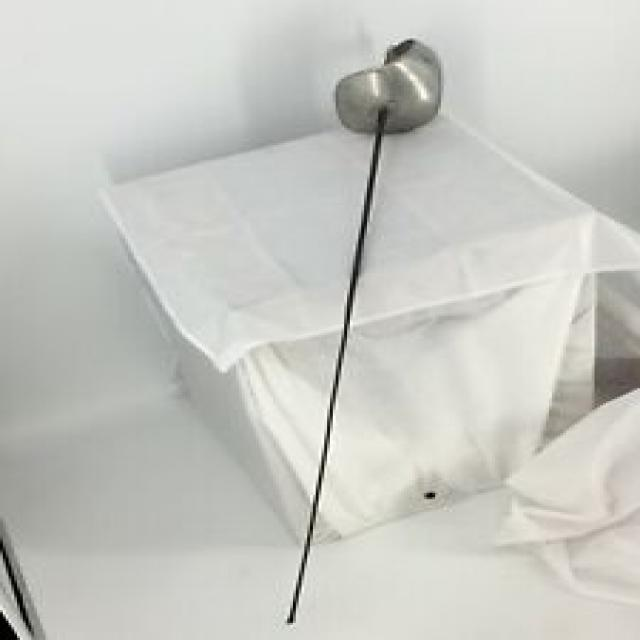

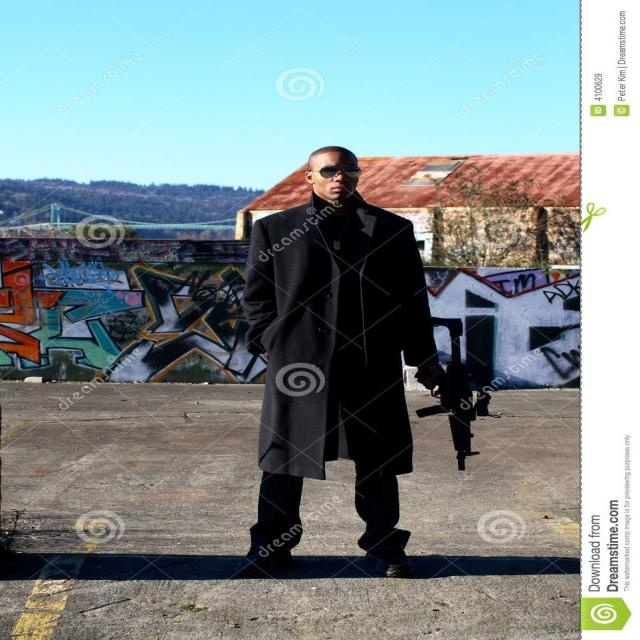

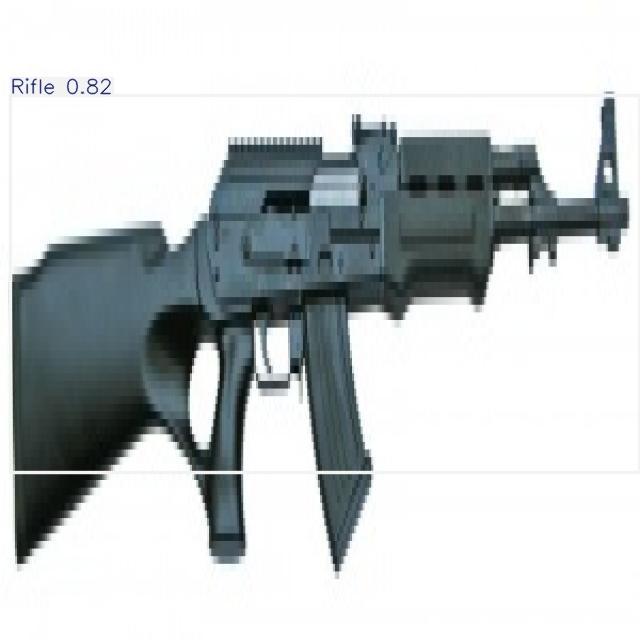

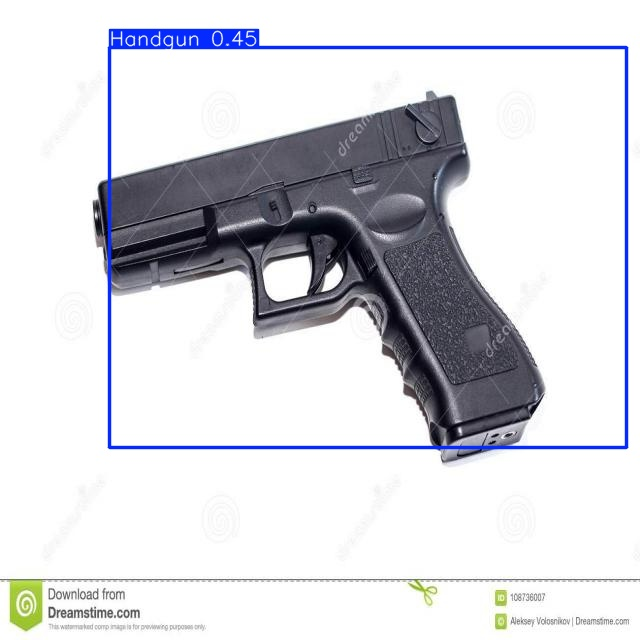

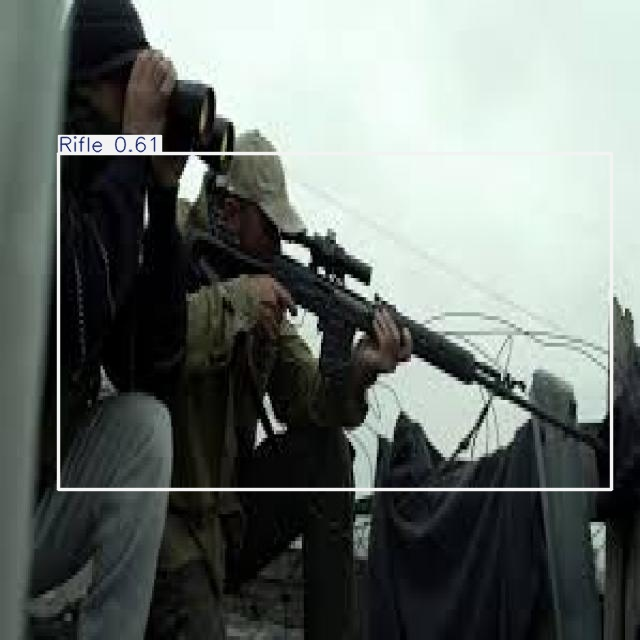

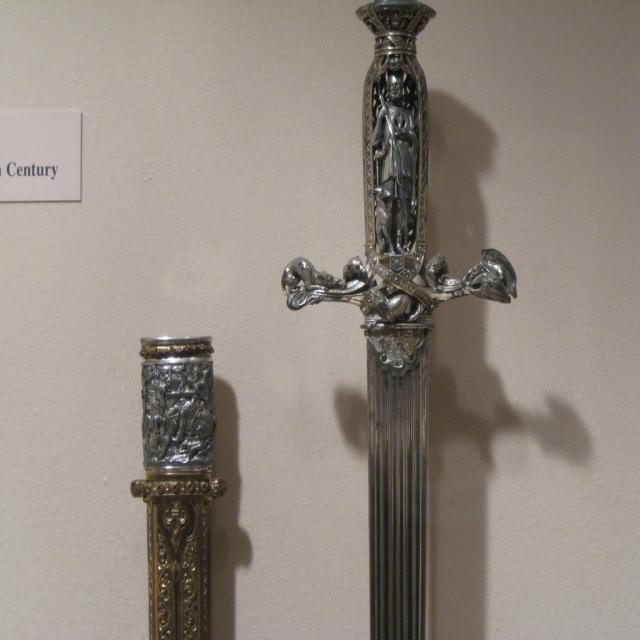

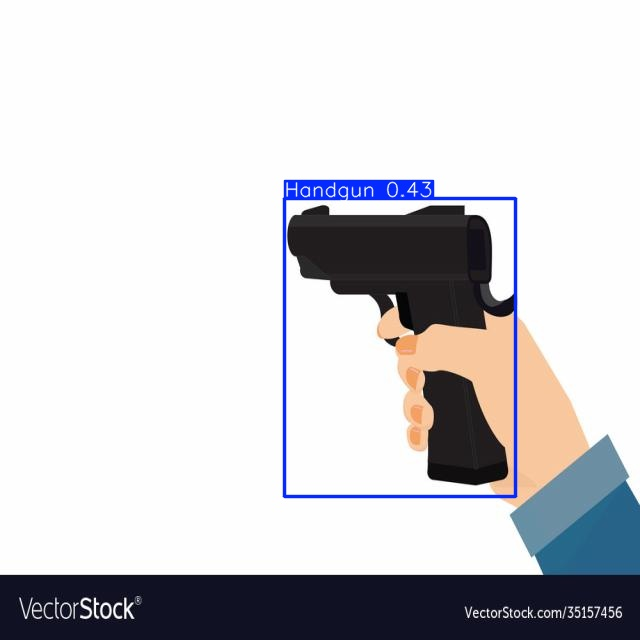

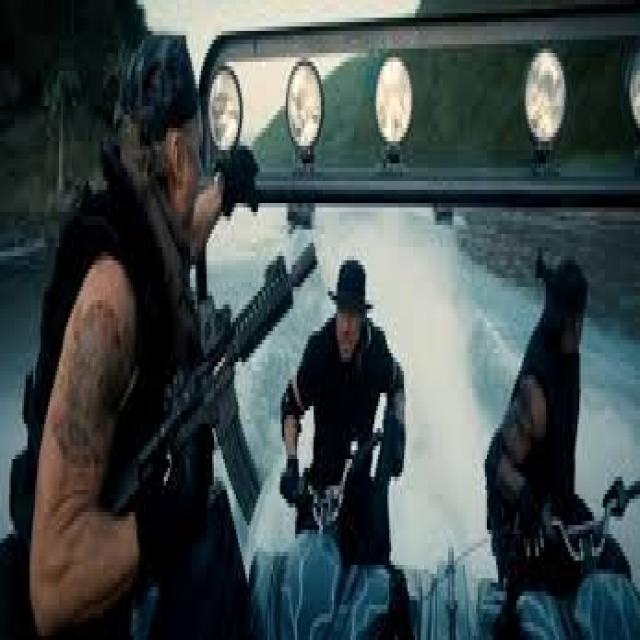

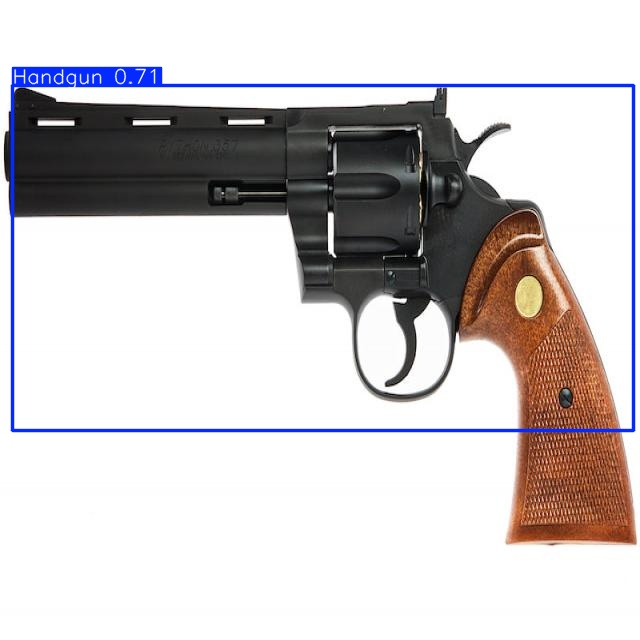

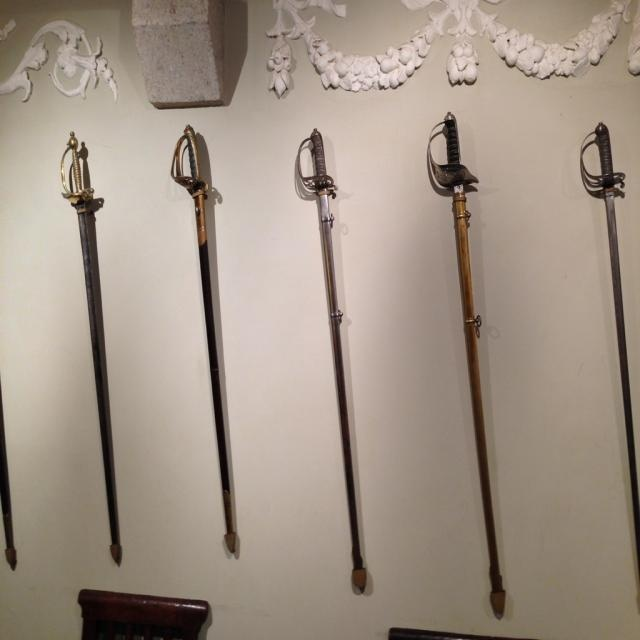

In [15]:
prediction_dir = "runs/detect/weapon_detection_test_predictions"
predicted_images = glob.glob(os.path.join(prediction_dir, "*"))

print("Number of predicted images:", len(predicted_images))

for img in predicted_images[:10]:
    display(Image(filename=img, width=600))

In [19]:
uploaded = files.upload()
uploaded_image = list(uploaded.keys())[0]

single_result = best_model.predict(
    source=uploaded_image,
    conf=0.4,
    save=True,
    name="weapon_detection_uploaded_image"
)

print("Prediction completed on uploaded image.")

Saving pistel.jpg to pistel.jpg

image 1/1 /content/pistel.jpg: 448x640 1 Handgun, 110.6ms
Speed: 2.9ms preprocess, 110.6ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/weapon_detection_uploaded_image-2
Prediction completed on uploaded image.


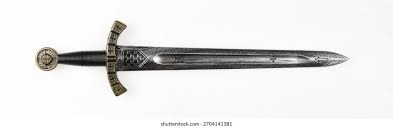

In [22]:
uploaded_prediction_dir = "runs/detect/weapon_detection_uploaded_image"
uploaded_pred_images = glob.glob(os.path.join(uploaded_prediction_dir, "*"))

for img in uploaded_pred_images:
    display(Image(filename=img, width=700))

In [23]:
detections = []

for result in single_result:
    names = result.names

    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        label = names[cls_id]

        detections.append({
            "Detected Object": label,
            "Confidence Score": round(conf, 3)
        })

if len(detections) == 0:
    print("No weapon/object detected.")
else:
    display(pd.DataFrame(detections))

,Detected Object,Confidence Score
0,Handgun,0.882


In [24]:
import glob

# Search all best.pt files inside runs folder
best_model_paths = glob.glob("/content/runs/**/best.pt", recursive=True)

print("Available best.pt model files:")
for i, path in enumerate(best_model_paths):
    print(i, path)

if len(best_model_paths) == 0:
    print("No best.pt found. Please train the model first.")
else:
    best_model_path = best_model_paths[-1]
    print("Using model:", best_model_path)

Available best.pt model files:
0 /content/runs/detect/weapon_detection_yolov8_roboflow/weights/best.pt
Using model: /content/runs/detect/weapon_detection_yolov8_roboflow/weights/best.pt


In [25]:
!pip install yt-dlp -q

from ultralytics import YOLO
import glob
from IPython.display import HTML
from base64 import b64encode

# Automatically find best.pt
best_model_paths = glob.glob("/content/runs/**/best.pt", recursive=True)

if len(best_model_paths) == 0:
    raise FileNotFoundError("No best.pt found. Train your YOLO model first, then run this cell again.")

best_model_path = best_model_paths[-1]
print("Loaded model:", best_model_path)

best_model = YOLO(best_model_path)

# Paste video URL here
video_url = "https://www.youtube.com/shorts/UfphLS5MVKQ"

# Download video
video_path = "weapon_test_video.mp4"
!yt-dlp -f "mp4/best" -o "{video_path}" "{video_url}"

print("Video downloaded successfully:", video_path)

# Run prediction and save output
video_results = best_model.predict(
    source=video_path,
    conf=0.4,
    save=True,
    name="weapon_detection_video"
)

print("Video prediction completed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 53.3 MB/s eta 0:00:00
Loaded model: /content/runs/detect/weapon_detection_yolov8_roboflow/weights/best.pt
[youtube] Extracting URL: https://www.youtube.com/shorts/UfphLS5MVKQ
[youtube] UfphLS5MVKQ: Downloading webpage
[youtube] UfphLS5MVKQ: Downloading android vr player API JSON
[info] UfphLS5MVKQ: Downloading 1 format(s): 18
[download] Destination: weapon_test_video.mp4
[download] 100% of    4.27MiB in 00:00:00 at 6.41MiB/s
Video downloaded successfully: weapon_test_video.mp4

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes objec